# CNN with Featured data Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [1]:
# Import necessary libraries
import os
import json
import numpy as np
import pandas as pd
import h5py
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.backend as K
from datetime import datetime


print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Reprodutibilidade
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score



TF: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Model Choice

As a baseline model, we implement the reference architecture provided in the challenge description:
a **3-layer 1D Convolutional Neural Network (CNN)**.

The architecture consists of:
- Two convolution + max-pooling blocks (each pooling with factor 10),
- One final convolution layer producing a 1 Hz probability sequence (90 values per window).

This baseline is appropriate because:
1. It is the official benchmark model of the challenge.
2. It processes raw PSG signals sampled at 100 Hz without handcrafted features.
3. It outputs a 1 Hz segmentation mask aligned with the provided ground-truth labels.
4. It provides a simple reference point for comparison with more complex architectures.

The model does not incorporate recurrence or attention mechanisms by design.




## Feature Selection

Each training example consists of:
- **8 PSG channels** sampled at **100 Hz**, resulting in input tensors of shape `(9000, 8)` for each 90-second window.
- A **binary segmentation mask** of shape `(90,)`, sampled at 1 Hz.

No handcrafted features are used.
The only preprocessing step applied is **signal normalization**, performed prior to training.

Subject identifiers are provided separately and are used exclusively to perform a
**subject-wise train/validation split**, preventing data leakage.



In [3]:
# Paths
IN_PATH = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\00_DataProcessing\02_Feature_Eng\nights_train_features_1hz.h5"

with h5py.File(IN_PATH, "r") as f:
    X_feat = f["X_feat"][:]         # (n_subj, 18000, n_feat)
    y  = f["y_nights"][:]       # (n_subj, 18000) @ 100Hz
    subj   = f["subject_ids"][:]    # (n_subj,)
    feature_names = [x.decode() for x in f["feature_names"][:]]


print("X_feat:", X_feat.shape)
print("y:", y.shape)
print("subj:", subj.shape)

X_feat: (22, 18000, 18)
y: (22, 18000)
subj: (22,)


In [4]:
#imprimir head y
print("y head:", y[0, :100])

y head: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [5]:
def chunk_generator(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=1):
    chunk_len = chunk_sec * fs
    stride_len = stride_sec * fs

    n_nights, T, C = X_nights.shape
    assert y_nights.shape[0] == n_nights
    assert y_nights.shape[1] == T // fs, f"y needs to have {T//fs} steps (1Hz) per night"

    for n in range(n_nights):
        X = X_nights[n]   # (T, 8) at 100Hz
        y = y_nights[n]   # (T//100,) at 1Hz
        for start in range(0, T - chunk_len + 1, stride_len):
            end = start + chunk_len

            X_chunk = X[start:end]
            y_chunk = y[start//fs : end//fs]

            # sanity: garante alinhamento perfeito
            if y_chunk.shape[0] != chunk_sec:
                continue

            yield X_chunk.astype("float32"), y_chunk.astype("float32")


In [6]:
#overlap = chunk − stride = 300 − 60 = 240 seconds 80% overlap
# stride = 120s → overlap = 180s (60%)
# stride = 150s → overlap = 150s (50%)
# stride = 300s → overlap = 0 (no overlap, but worse coverage)
CHUNK_SEC = 300  #5-minute (300s) windows 
STRIDE_SEC = 60
FS = 1

gen = chunk_generator(X_feat, y, chunk_sec=CHUNK_SEC, stride_sec=STRIDE_SEC, fs=FS)
Xc, yc = next(gen)
print(Xc.shape, yc.shape)          # (30000, 8) (300,)
print("chunk % ones:", yc.mean()*100)


(300, 18) (300,)
chunk % ones: 5.33333346247673


In [7]:
def make_tf_dataset(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=1,
                    batch_size=4, shuffle_buffer=1024):
    chunk_len = chunk_sec * fs

    output_signature = (
        tf.TensorSpec(shape=(chunk_len, 8), dtype=tf.float32),
        tf.TensorSpec(shape=(chunk_sec,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: chunk_generator(X_nights, y_nights, chunk_sec, stride_sec, fs),
        output_signature=output_signature
    )

    ds = ds.shuffle(shuffle_buffer, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [8]:
SEED = 42
rng = np.random.default_rng(SEED)
idx = np.arange(22)
rng.shuffle(idx)

n_train = int(0.7 * len(idx))  # 15
train_idx = idx[:n_train]
val_idx   = idx[n_train:]

X_train = X_feat[train_idx]
y_train = y[train_idx]
X_val   = X_feat[val_idx]
y_val   = y[val_idx]

In [9]:
# ========================================
# 1. CARREGAR DADOS (CORRIGIR y_raw → y)
# ========================================
IN_PATH = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\00_DataProcessing\02_Feature_Eng\nights_train_features_1hz.h5"

with h5py.File(IN_PATH, "r") as f:
    X_feat = f["X_feat"][:]         # (22, 18000, n_feat)
    y = f["y_nights"][:]            # (22, 18000) @ 1Hz ✅ CORRIGIDO
    subj = f["subject_ids"][:]
    feature_names = [x.decode() for x in f["feature_names"][:]]

print("X_feat:", X_feat.shape)
print("y:", y.shape)  # ✅ CORRIGIDO (era y_raw)
print("n_features:", X_feat.shape[2])
print("subj:", subj.shape)

# ========================================
# 2. CHUNK GENERATOR PARA FEATURES @ 1Hz
# ========================================
def chunk_generator(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=1):
    """
    Para features @ 1Hz:
    X_nights: (n_nights, T, n_feat) onde T @ 1Hz
    y_nights: (n_nights, T) @ 1Hz
    """
    chunk_len = chunk_sec * fs      # 300 * 1 = 300
    stride_len = stride_sec * fs    # 60 * 1 = 60

    n_nights, T, C = X_nights.shape
    assert y_nights.shape[0] == n_nights, f"n_nights mismatch"
    assert y_nights.shape[1] == T, f"y precisa ter {T} @ {fs}Hz, mas tem {y_nights.shape[1]}"

    for n in range(n_nights):
        X = X_nights[n]   # (18000, n_feat) @ 1Hz
        y_n = y_nights[n] # (18000,) @ 1Hz
        
        for start in range(0, T - chunk_len + 1, stride_len):
            end = start + chunk_len
            
            X_chunk = X[start:end]     # (300, n_feat)
            y_chunk = y_n[start:end]   # (300,)
            
            if y_chunk.shape[0] != chunk_sec:
                continue
                
            yield X_chunk.astype("float32"), y_chunk.astype("float32")

# ========================================
# 3. TF DATASET CORRIGIDO PARA N_FEAT
# ========================================
def make_tf_dataset(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=1,
                    batch_size=4, shuffle_buffer=1024):
    """Para features @ 1Hz com número dinâmico de features"""
    chunk_len = chunk_sec * fs  # 300
    n_feat = X_nights.shape[2]  # ✅ NÚMERO DE FEATURES (não hardcoded!)
    
    output_signature = (
        tf.TensorSpec(shape=(chunk_len, n_feat), dtype=tf.float32),  # ✅ (300, n_feat)
        tf.TensorSpec(shape=(chunk_sec,), dtype=tf.float32),         # ✅ (300,)
    )
    
    ds = tf.data.Dataset.from_generator(
        lambda: chunk_generator(X_nights, y_nights, chunk_sec, stride_sec, fs),
        output_signature=output_signature
    )
    
    ds = ds.shuffle(shuffle_buffer, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# ========================================
# 4. TESTE DO GERADOR
# ========================================
CHUNK_SEC = 300
STRIDE_SEC = 60
FS = 1

print("\n=== Teste do Gerador ===")
gen = chunk_generator(X_feat, y, chunk_sec=CHUNK_SEC, stride_sec=STRIDE_SEC, fs=FS)
Xc, yc = next(gen)
print(f"Xc.shape: {Xc.shape}")  # Esperado: (300, n_feat)
print(f"yc.shape: {yc.shape}")  # Esperado: (300,)
print(f"chunk % ones: {yc.mean()*100:.2f}%")

# ========================================
# 5. SPLIT TRAIN/VAL
# ========================================
SEED = 42
rng = np.random.default_rng(SEED)
idx = np.arange(22)
rng.shuffle(idx)

n_train = int(0.7 * len(idx))
train_idx = idx[:n_train]
val_idx = idx[n_train:]

X_train = X_feat[train_idx]
y_train = y[train_idx]
X_val = X_feat[val_idx]
y_val = y[val_idx]

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")
print(f"Train % ones: {y_train.mean()*100:.2f}%")
print(f"Val % ones: {y_val.mean()*100:.2f}%")

# ========================================
# 6. CRIAR DATASETS E VALIDAR
# ========================================
CHUNK_SEC = 300
STRIDE_SEC = 60
BATCH_SIZE = 4
FS = 1

train_ds = make_tf_dataset(X_train, y_train, 
                          chunk_sec=CHUNK_SEC, 
                          stride_sec=STRIDE_SEC, 
                          fs=FS, 
                          batch_size=BATCH_SIZE)

val_ds = make_tf_dataset(X_val, y_val, 
                        chunk_sec=CHUNK_SEC, 
                        stride_sec=STRIDE_SEC, 
                        fs=FS, 
                        batch_size=BATCH_SIZE)

print(f"\nTrain batches: {train_ds.cardinality().numpy()}")
print(f"Val batches: {val_ds.cardinality().numpy()}")

# ========================================
# 7. VALIDAÇÃO FINAL DO BATCH
# ========================================
for xb, yb in train_ds.take(1):
    print(f"\n=== Validação do Batch ===")
    print(f"batch X: {xb.shape}")  # Esperado: (4, 300, n_feat)
    print(f"batch y: {yb.shape}")  # Esperado: (4, 300)
    print(f"n_features: {xb.shape[2]}")
    print(f"% ones no batch: {float(tf.reduce_mean(yb)) * 100:.2f}%")

# ✅ Validações CORRETAS para features @ 1Hz
assert xb.shape[0] == BATCH_SIZE, f"Batch size incorreto: {xb.shape[0]}"
assert xb.shape[1] == CHUNK_SEC, f"Chunk temporal incorreto: {xb.shape[1]}"  # 300!
assert yb.shape[1] == CHUNK_SEC, f"Label temporal incorreto: {yb.shape[1]}"
print(f"\n✅ Tudo OK! Shape final: {xb.shape}")

X_feat: (22, 18000, 18)
y: (22, 18000)
n_features: 18
subj: (22,)

=== Teste do Gerador ===
Xc.shape: (300, 18)
yc.shape: (300,)
chunk % ones: 5.33%

Train: (15, 18000, 18), Val: (7, 18000, 18)
Train % ones: 6.20%
Val % ones: 8.30%

Train batches: -2
Val batches: -2

=== Validação do Batch ===
batch X: (4, 300, 18)
batch y: (4, 300)
n_features: 18
% ones no batch: 19.08%

✅ Tudo OK! Shape final: (4, 300, 18)


In [10]:
#check the split mean, median, std
print("Train % ones:", y_train.mean()*100)
print("Val % ones:", y_val.mean()*100)
train_ds = make_tf_dataset(X_train, y_train,
                           chunk_sec=CHUNK_SEC,
                           stride_sec=STRIDE_SEC,
                           fs=FS,
                           batch_size=8,
                           shuffle_buffer=2048)
val_ds = make_tf_dataset(X_val, y_val,
                         chunk_sec=CHUNK_SEC,
                         stride_sec=STRIDE_SEC,  
                         fs=FS,
                         batch_size=8,
                         shuffle_buffer=2048)
print("Train batches:", train_ds.cardinality().numpy())
print("Val batches:", val_ds.cardinality().numpy())  

Train % ones: 6.204444444444444
Val % ones: 8.303174603174602
Train batches: -2
Val batches: -2


In [11]:
train_ds = make_tf_dataset(X_train, y_train, chunk_sec=300, stride_sec=60, batch_size=4)

val_ds   = make_tf_dataset(X_val,   y_val,   chunk_sec=300, stride_sec=60, batch_size=4, shuffle_buffer=256)

In [12]:
CHUNK_SEC = 300
STRIDE_SEC = 60
BATCH_SIZE = 4
FS = 1

train_ds = make_tf_dataset(X_train, y_train, chunk_sec=CHUNK_SEC, stride_sec=STRIDE_SEC, fs=FS, batch_size=BATCH_SIZE)

# for xb, yb in train_ds.take(1):
#     print("batch X:", xb.shape, "batch y:", yb.shape)  # (4, 300, n_feat    CHUNK_SEC = 300
#     STRIDE_SEC = 60
#     BATCH_SIZE = 4
#     FS = 1  # Features @ 1Hz
    
#     train_ds = make_tf_dataset(X_train, y_train, 
#                               chunk_sec=CHUNK_SEC, 
#                               stride_sec=STRIDE_SEC, 
#                               fs=FS, 
#                               batch_size=BATCH_SIZE)
    
for xb, yb in train_ds.take(1):
    print("batch X:", xb.shape, "batch y:", yb.shape)
    # Esperado: (4, 300, n_feat) e (4, 300) para features @ 1Hz
    print("n_features:", xb.shape[2])
    print("✅ Shapes corretos para features @ 1Hz")
        
# Validações
assert xb.shape[0] == BATCH_SIZE, f"Batch size incorreto: {xb.shape[0]}"
assert xb.shape[1] == CHUNK_SEC, f"Chunk temporal incorreto: {xb.shape[1]}"
assert yb.shape[1] == CHUNK_SEC, f"Label temporal incorreto: {yb.shape[1]}"
print(f"✅ Tudo OK! Shape: {xb.shape}")


batch X: (4, 300, 18) batch y: (4, 300)
n_features: 18
✅ Shapes corretos para features @ 1Hz
✅ Tudo OK! Shape: (4, 300, 18)


In [14]:
# 1) conferência de comprimento (sempre verdadeiro)
assert xb.shape[1] == 300 * 1
assert yb.shape[1] == 300

# 2) sanity do balanceamento no batch
print("true % ones no batch:", float(tf.reduce_mean(yb)) * 1)


true % ones no batch: 0.08916667103767395


## Implementation

Below we implement the 3-layer CNN baseline as specified by the challenge.
Two Conv1D + MaxPool1D blocks downsample the 100 Hz signal to 1 Hz, and the final
Conv1D layer outputs class probabilities for each of the 90 seconds.


CNN Baseline model

In [15]:
FS = 1
CHUNK_SEC = 300
N_SAMPLES = CHUNK_SEC   # ✅ 300 (não FS * CHUNK_SEC!)
N_CHANNELS = X_feat.shape[2]  # número de features

def build_baseline_cnn():
    """
    Modelo para FEATURES @ 1Hz
    Input: (batch, 300, n_feat)
    Output: (batch, 300)
    """
    model = models.Sequential([
        layers.Input(shape=(N_SAMPLES, N_CHANNELS)),
        
        # Conv blocks SEM downsampling (dados já estão @ 1Hz)
        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        
        # Output layer
        layers.Conv1D(1, kernel_size=1, padding='same', activation='sigmoid'),
        layers.Lambda(lambda t: tf.squeeze(t, axis=-1))  # (batch, 300)
    ])
    return model

model = build_baseline_cnn()
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 300, 32)           2912      
                                                                 
 conv1d_1 (Conv1D)           (None, 300, 32)           5152      
                                                                 
 conv1d_2 (Conv1D)           (None, 300, 64)           6208      
                                                                 
 conv1d_3 (Conv1D)           (None, 300, 64)           12352     
                                                                 
 conv1d_4 (Conv1D)           (None, 300, 1)            65        
                                                                 
 lambda (Lambda)             (None, 300)               0         
                                                                 
Total params: 26,689
Trainable params: 26,689
Non-traina

Loss Function (Weighted BCE)

In [16]:
positive_ratio = float(np.mean(y))
neg_ratio = 1.0 - positive_ratio
pos_weight = neg_ratio / (positive_ratio + 1e-12)
print("Positive ratio:", positive_ratio, "| pos_weight:", pos_weight)

def weighted_bce(pos_weight):
    def loss(y_true, y_pred):
        bce = K.binary_crossentropy(y_true, y_pred)
        w = 1.0 + (pos_weight - 1.0) * y_true
        return K.mean(bce * w)
    return loss




Positive ratio: 0.06872222222222223 | pos_weight: 13.551333872074434


In [ ]:
def focal_weighted_bce(pos_weight, gamma=2.0):
    """
    Focal Loss + Weighted BCE
    gamma: controla o foco em hard examples (padrão: 2.0)
    """
    def loss(y_true, y_pred):
        # BCE
        bce = K.binary_crossentropy(y_true, y_pred)
        
        # Focal term: diminui o peso de exemplos fáceis
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = K.pow(1 - p_t, gamma)
        
        # Weighted term: aumenta peso dos positivos
        sample_weight = 1.0 + (pos_weight - 1.0) * y_true
        
        # Combinar
        return K.mean(bce * focal_weight * sample_weight)
    
    return loss

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=focal_weighted_bce(pos_weight, gamma=2.0),  # ✅ FOCAL + WEIGHTED
#     metrics=[tf.keras.metrics.AUC(curve="PR", name="auc_pr")]
# )

#worst after this loss function
# night 0: TP=  1 | FP=131 | FN= 19 | true%= 1.39% | pred%=12.77%
# night 1: TP= 28 | FP=167 | FN= 68 | true%= 9.56% | pred%=20.47%
# night 2: TP= 62 | FP=213 | FN=130 | true%=27.24% | pred%=29.16%
# night 3: TP=  4 | FP=189 | FN= 17 | true%= 1.63% | pred%=18.95%
# night 4: TP=  5 | FP=203 | FN= 11 | true%= 2.90% | pred%=22.37%
# night 5: TP=  6 | FP=143 | FN= 12 | true%= 1.63% | pred%=12.04%
# night 6: TP= 35 | FP=185 | FN=119 | true%=13.77% | pred%=19.08%

Compile & Train

In [ ]:
# ========================================
# COMPILAÇÃO E CALLBACKS (CORRIGIDO)
# ========================================
lr = 1e-4  
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=weighted_bce(pos_weight),
    metrics=[tf.keras.metrics.AUC(curve="PR", name="auc_pr")]
)

# ✅ Definir diretório uma única vez
OUT_DIR = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured"
os.makedirs(OUT_DIR, exist_ok=True)

# ✅ Usar timestamp para diferenciar runs
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
ckpt_best = os.path.join(OUT_DIR, f"{run_id}_best.keras")
ckpt_last = os.path.join(OUT_DIR, f"{run_id}_last.keras")

print(f"✅ Checkpoints serão salvos em:\n   {OUT_DIR}")
print(f"   Best: {ckpt_best}")
print(f"   Last: {ckpt_last}")

# ✅ Callbacks corrigidos
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        patience=10, 
        restore_best_weights=True, 
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_best,             
        save_best_only=True, 
        monitor="val_loss", 
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", 
        factor=0.5, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    )
]

✅ Checkpoints serão salvos em:
   C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured
   Best: C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured\20260121_130225_best.keras
   Last: C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured\20260121_130225_last.keras


In [46]:
history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/70
   1109/Unknown - 16s 14ms/step - loss: 1.1606 - auc_pr: 0.1231
Epoch 1: val_loss improved from inf to 1.83083, saving model to C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured\20260121_130225_best.keras
1110/1110 [==============================] - 21s 18ms/step - loss: 1.1600 - auc_pr: 0.1231 - val_loss: 1.8308 - val_auc_pr: 0.1051 - lr: 1.0000e-04
Epoch 2/70
1110/1110 [==============================] - ETA: 0s - loss: 1.1313 - auc_pr: 0.1376
Epoch 2: val_loss did not improve from 1.83083
1110/1110 [==============================] - 20s 18ms/step - loss: 1.1313 - auc_pr: 0.1376 - val_loss: 2.0156 - val_auc_pr: 0.1066 - lr: 1.0000e-04
Epoch 3/70
1108/1110 [============================>.] - ETA: 0s - loss: 1.1174 - auc_pr: 0.1473
Epoch 3: val_loss improved from 1.83083 to 1.82108, saving model to C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\3_Model\3lcnn_featured\20260121_130225_best.keras
1110/1110 [==============================] - 21s 19ms/step -

In [ ]:
#save history as pickle
import pickle
with open(os.path.join(OUT_DIR, f"{run_id}_history.pkl"), "wb") as f:
    pickle.dump(history.history, f)



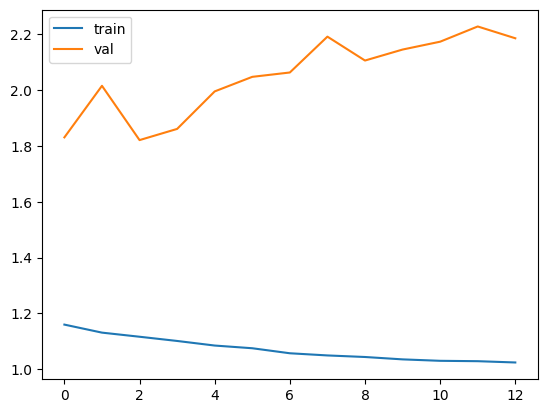

In [47]:
plt.plot(history3.history["loss"], label="train")
plt.plot(history3.history["val_loss"], label="val")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GroupKFold

def build_baseline_cnn(n_samples, n_channels):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_samples, n_channels)),
        tf.keras.layers.Conv1D(32, 5, padding="same", activation="relu"),
        tf.keras.layers.Conv1D(32, 5, padding="same", activation="relu"),
        tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.Conv1D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.Conv1D(1, 1, padding="same", activation="sigmoid"),
        tf.keras.layers.Lambda(lambda t: tf.squeeze(t, axis=-1)),  # (B, 300)
    ])
    return model

def train_kfold_seq2seq(
    X, Y, groups,
    n_splits=5,
    batch_size=32,
    epochs=30,
    lr=1e-3,
    seed=42
):
    gkf = GroupKFold(n_splits=n_splits)

    oof_pred = np.zeros_like(Y, dtype=np.float32)  # (N, 300)
    fold_models = []

    for fold, (tr, va) in enumerate(gkf.split(X, Y, groups=groups), start=1):
        print(f"\n=== Fold {fold}/{n_splits} ===")
        tf.keras.utils.set_random_seed(seed + fold)

        model = build_baseline_cnn(n_samples=X.shape[1], n_channels=X.shape[2])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
            loss="binary_crossentropy",
            metrics=[tf.keras.metrics.AUC(curve="PR", name="auprc")]
        )

        ckpt = f"/mnt/data/cnn_fold{fold}.weights.h5"
        cbs = [
            tf.keras.callbacks.ModelCheckpoint(
                ckpt, monitor="val_auprc", mode="max",
                save_best_only=True, save_weights_only=True, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auprc", mode="max",
                patience=6, restore_best_weights=True, verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_auprc", mode="max",
                factor=0.5, patience=3, min_lr=1e-6, verbose=1
            )
        ]

        model.fit(
            X[tr], Y[tr],
            validation_data=(X[va], Y[va]),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=cbs,
            verbose=2
        )

        pred_va = model.predict(X[va], batch_size=batch_size, verbose=0)  # (n_va, 300)
        oof_pred[va] = pred_va.astype(np.float32)

        fold_models.append(model)

    return oof_pred, fold_models


In [ ]:
build_model

## Evaluation

Model performance is evaluated using an **event-based F1-score**, consistent with the
official metric of the Dreem Sleep Apnea Challenge.

Predictions are first reconstructed at **1 Hz over the full night** by aggregating
overlapping window-level outputs using an overlap-and-average strategy. The resulting
probability sequence is then thresholded to obtain a binary apnea mask.

Apnea events are extracted as contiguous segments in the binary mask and compared to the
ground-truth annotations using an **Intersection over Union (IoU)** criterion. A predicted
event is considered a true positive if its IoU with a reference event is greater than or
equal to **0.3**.

The final score is computed as an **event-level F1-score**, aggregating true positives,
false positives, and false negatives across all validation nights.

For completeness, window-level metrics such as accuracy and recall may be reported for
debugging purposes, but **they are not used for model selection**, as they do not reflect
the temporal structure of apnea events.



In [ ]:
best_frozen = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\3lcnn_night\20251214_014656_BEST_frozen.keras"

model = tf.keras.models.load_model(best_frozen, compile = False)
print("Modelo carregado:", best_frozen)


In [48]:
def predict_nights_overlap_mean(
    model,
    X_nights,                 # (n_nights, 1800000, 8)
    chunk_sec=300,
    stride_sec=60,
    fs=1,
    batch_size=4
):
    n_nights, T, C = X_nights.shape
    chunk_len = chunk_sec * fs        # 300
    stride_len = stride_sec * fs      # 60
    T1 = T // fs                      # 18000

    y_sum = np.zeros((n_nights, T1), dtype=np.float32)
    y_cnt = np.zeros((n_nights, T1), dtype=np.float32)

    for n in range(n_nights):
        X = X_nights[n]  # (1800000, 8)
        starts = range(0, T - chunk_len + 1, stride_len)

        batch_X = []
        batch_ranges = []

        for start in starts:
            end = start + chunk_len
            x_chunk = X[start:end]          # (30000, 8)

            s1 = start // fs
            e1 = end // fs                  # 300 pontos

            batch_X.append(x_chunk)
            batch_ranges.append((s1, e1))

            if len(batch_X) == batch_size:
                preds = model.predict(np.stack(batch_X).astype("float32"), verbose=0)  # (B, 300)
                for p, (s1_, e1_) in zip(preds, batch_ranges):
                    y_sum[n, s1_:e1_] += p
                    y_cnt[n, s1_:e1_] += 1.0
                batch_X, batch_ranges = [], []

        if batch_X:
            preds = model.predict(np.stack(batch_X).astype("float32"), verbose=0)
            for p, (s1_, e1_) in zip(preds, batch_ranges):
                y_sum[n, s1_:e1_] += p
                y_cnt[n, s1_:e1_] += 1.0

    return y_sum / np.maximum(y_cnt, 1.0)


In [49]:
y_pred_val_nights = predict_nights_overlap_mean(
    model,
    X_val,                 # (n_val, 180, 8)
    chunk_sec=300,
    stride_sec=60,
    fs=1,
    batch_size=4
)

print(y_pred_val_nights.shape)  # esperado: (n_val, 180)


(7, 18000)


In [50]:

print("y_pred_val_nights:", y_pred_val_nights.shape)  # (n_val, 18000)
print("min/max/mean:", y_pred_val_nights.min(), y_pred_val_nights.max(), y_pred_val_nights.mean())


y_pred_val_nights: (7, 18000)
min/max/mean: 0.0 1.0 0.4543513


In [51]:
def extract_events_from_binary_mask(binary_mask, fs=1):
    binary_mask = np.asarray(binary_mask).astype(int)
    padded = np.concatenate([[0], binary_mask, [0]])
    diff = np.diff(padded)
    starts = np.where(diff == 1)[0] / fs
    ends   = np.where(diff == -1)[0] / fs
    return [(float(s), float(e)) for s, e in zip(starts, ends)]

def jaccard_overlap(pred_events, true_events):
    # rows=true, cols=pred
    A = len(pred_events)
    B = len(true_events)
    if A == 0 or B == 0:
        return np.zeros((B, A), dtype=np.float32)

    p_start = np.array([s for s, e in pred_events])[None, :]
    p_end   = np.array([e for s, e in pred_events])[None, :]
    t_start = np.array([s for s, e in true_events])[:, None]
    t_end   = np.array([e for s, e in true_events])[:, None]

    inter = np.maximum(np.minimum(p_end, t_end) - np.maximum(p_start, t_start), 0.0)
    union = (p_end - p_start) + (t_end - t_start) - inter + 1e-12
    return (inter / union).astype(np.float32)

def tp_fp_fn(pred_events, true_events, min_iou=0.3):
    if len(pred_events) == 0:
        return 0, 0, len(true_events)
    if len(true_events) == 0:
        return 0, len(pred_events), 0

    iou = jaccard_overlap(pred_events, true_events)  # (n_true, n_pred)
    matched_true = int(np.any(iou >= min_iou, axis=1).sum())
    matched_pred = int(np.any(iou >= min_iou, axis=0).sum())

    tp = int(min(matched_true, matched_pred))
    fp = len(pred_events) - tp
    fn = len(true_events) - tp
    return tp, fp, fn

def event_f1_nights(y_pred_bin_nights, y_true_nights, min_iou=0.3):
    total_tp = total_fp = total_fn = 0
    for yp, yt in zip(y_pred_bin_nights, y_true_nights):
        pred_events = extract_events_from_binary_mask(yp, fs=1)
        true_events = extract_events_from_binary_mask(yt, fs=1)
        tp, fp, fn = tp_fp_fn(pred_events, true_events, min_iou=min_iou)
        total_tp += tp; total_fp += fp; total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-12)
    recall    = total_tp / (total_tp + total_fn + 1e-12)
    return float(2 * precision * recall / (precision + recall + 1e-12))


In [52]:
# y_valN deve ser (7, 18000) 0/1
y_true_val_nights = y_val.astype(int)

best_t, best_f1 = None, -1
for t in np.linspace(0.20, 0.80, 31):
    yb = (y_pred_val_nights >= t).astype(int)
    f1 = event_f1_nights(yb, y_true_val_nights, min_iou=0.3)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("BEST threshold:", best_t)
print("BEST Event-F1:", best_f1)


BEST threshold: 0.36000000000000004
BEST Event-F1: 0.09439707673554311


In [53]:
def postprocess_mask(mask, min_len=10, gap_fill=5):
    """
    mask: (T,) 0/1 em 1Hz
    min_len: remove eventos com duração < min_len segundos
    gap_fill: preenche buracos de zeros com duração <= gap_fill dentro de um evento
    """
    m = mask.astype(int).copy()
    T = len(m)

    # 1) fill small gaps (0-runs curtos entre 1s)
    i = 0
    while i < T:
        if m[i] == 0:
            j = i
            while j < T and m[j] == 0:
                j += 1
            gap = j - i
            left_one = (i - 1 >= 0 and m[i - 1] == 1)
            right_one = (j < T and m[j] == 1)
            if left_one and right_one and gap <= gap_fill:
                m[i:j] = 1
            i = j
        else:
            i += 1

    # 2) remove short events (1-runs curtos)
    i = 0
    while i < T:
        if m[i] == 1:
            j = i
            while j < T and m[j] == 1:
                j += 1
            run = j - i
            if run < min_len:
                m[i:j] = 0
            i = j
        else:
            i += 1

    return m


In [54]:
best = (-1, None)

for t in np.linspace(0.2, 0.8, 31):
    raw = (y_pred_val_nights >= t).astype(int)

    for min_len in [1, 2, 3, 5, 8, 10, 12, 15]:
        for gap_fill in [0, 1, 2, 3, 5]:
            ypp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                            for i in range(raw.shape[0])])
            f1 = event_f1_nights(ypp, y_val.astype(int), min_iou=0.3)

            if f1 > best[0]:
                best = (f1, (t, min_len, gap_fill))

print("BEST postproc Event-F1:", best[0])
print("params (t, min_len, gap_fill):", best[1])
#print porcentage of 1 
t = best[1][0]
min_len = best[1][1]
gap_fill = best[1][2]

raw = (y_pred_val_nights >= t).astype(int)
y_pp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                 for i in range(raw.shape[0])])
print("Percentage of 1s after post-processing:", y_pp.mean() * 100)

BEST postproc Event-F1: 0.20008302200049297
params (t, min_len, gap_fill): (0.48000000000000004, 15, 1)
Percentage of 1s after post-processing: 54.48333333333333


In [29]:

from itertools import product


In [30]:
def moving_average(p, w):
    if w <= 1:
        return p
    kernel = np.ones(w) / w
    return np.convolve(p, kernel, mode="same")


In [31]:
def postprocess_mask(mask, min_len=10, gap_fill=5):
    m = mask.astype(int).copy()
    T = len(m)

    # fill small gaps
    i = 0
    while i < T:
        if m[i] == 0:
            j = i
            while j < T and m[j] == 0:
                j += 1
            gap = j - i
            if i > 0 and j < T and m[i-1] == 1 and m[j] == 1 and gap <= gap_fill:
                m[i:j] = 1
            i = j
        else:
            i += 1

    # remove short events
    i = 0
    while i < T:
        if m[i] == 1:
            j = i
            while j < T and m[j] == 1:
                j += 1
            if j - i < min_len:
                m[i:j] = 0
            i = j
        else:
            i += 1

    return m


In [32]:
def postprocess_from_probs(p, smooth_w, q, min_len, gap_fill):
    p = np.asarray(p, float)

    # 1) smoothing
    p_s = moving_average(p, smooth_w)

    # 2) threshold adaptativo por noite (percentil)
    t = np.percentile(p_s, q)
    raw = (p_s >= t).astype(int)

    # 3) gap fill + min_len
    return postprocess_mask(raw, min_len=min_len, gap_fill=gap_fill)


In [33]:
def eval_on_val(y_pred_val_nights, y_true_val_nights, params):
    f1s = []
    for p_night, y_valN in zip(y_pred_val_nights, y_true_val_nights):
        ypp = postprocess_from_probs(p_night, **params)

        f1 = event_f1_nights(
            [ypp],                      # <<< aqui
            [y_valN.astype(int)],       # <<< aqui
            min_iou=0.3
        )
        f1s.append(f1)

    return float(np.mean(f1s))


In [55]:
from itertools import product

results = []

grid = {
    "smooth_w": [1, 5, 10],          # segundos
    "q": [92, 94, 96, 97, 98, 99],   # percentil por noite
    "min_len": [3, 5, 8, 10, 12],    # segundos
    "gap_fill": [1, 3, 5],           # segundos
}

for smooth_w, q, min_len, gap_fill in product(
    grid["smooth_w"],
    grid["q"],
    grid["min_len"],
    grid["gap_fill"],
):
    params = dict(
        smooth_w=smooth_w,
        q=q,
        min_len=min_len,
        gap_fill=gap_fill,
    )

    f1 = eval_on_val(
        y_pred_val_nights,
        y_true_val_nights,
        params
    )

    results.append((f1, params))

results.sort(key=lambda x: x[0], reverse=True)

best_f1, best_params = results[0]
print("BEST VAL Event-F1:", best_f1)
print("BEST PARAMS:", best_params)
print("Percentage of 1s after post-processing:",
      np.mean([postprocess_from_probs(
          y_pred_val_nights[i], **best_params
      ).mean() for i in range(y_pred_val_nights.shape[0])]) * 100)


BEST VAL Event-F1: 0.11826921405130224
BEST PARAMS: {'smooth_w': 10, 'q': 92, 'min_len': 10, 'gap_fill': 1}
Percentage of 1s after post-processing: 5.31984126984127


In [58]:
import numpy as np
from itertools import product

def moving_average(p, w):
    if w <= 1:
        return p
    kernel = np.ones(w) / w
    return np.convolve(p, kernel, mode="same")

def postprocess_mask(mask, min_len=10, gap_fill=5):
    m = mask.astype(int).copy()
    T = len(m)

    # fill small gaps
    i = 0
    while i < T:
        if m[i] == 0:
            j = i
            while j < T and m[j] == 0:
                j += 1
            gap = j - i
            if i > 0 and j < T and m[i-1] == 1 and m[j] == 1 and gap <= gap_fill:
                m[i:j] = 1
            i = j
        else:
            i += 1

    # remove short events
    i = 0
    while i < T:
        if m[i] == 1:
            j = i
            while j < T and m[j] == 1:
                j += 1
            if j - i < min_len:
                m[i:j] = 0
            i = j
        else:
            i += 1

    return m

def postprocess_from_probs_z(p, smooth_w, z_thr, min_len, gap_fill):
    p = np.asarray(p, float)
    p_s = moving_average(p, smooth_w)

    mu = p_s.mean()
    sd = p_s.std() + 1e-8
    pz = (p_s - mu) / sd

    raw = (pz >= z_thr).astype(int)
    return postprocess_mask(raw, min_len=min_len, gap_fill=gap_fill)

def eval_on_val_z(y_pred_val_nights, y_true_val_nights, params):
    f1s = []
    for p_night, y_valN in zip(y_pred_val_nights, y_true_val_nights):
        ypp = postprocess_from_probs_z(p_night, **params)

        # sua função espera "lista de noites"
        f1 = event_f1_nights([ypp], [y_valN.astype(int)], min_iou=0.3)
        f1s.append(f1)
    return float(np.mean(f1s))

# ===== GRID =====
results = []

grid = {
    "smooth_w": [1, 3, 5, 10],             # s
    "z_thr":    [-0.5, 0.0, 0.5, 1.0, 1.5, 2.0],
    "min_len":  [2, 3, 5, 8, 10, 12],      # s
    "gap_fill": [1, 2, 3, 5],              # s
}

for smooth_w, z_thr, min_len, gap_fill in product(
    grid["smooth_w"], grid["z_thr"], grid["min_len"], grid["gap_fill"]
):
    params = dict(smooth_w=smooth_w, z_thr=z_thr, min_len=min_len, gap_fill=gap_fill)
    f1 = eval_on_val_z(y_pred_val_nights, y_true_val_nights, params)
    results.append((f1, params))

results.sort(key=lambda x: x[0], reverse=True)
best_f1, best_params = results[0]
print("BEST VAL Event-F1:", best_f1)
print("BEST PARAMS:", best_params)


BEST VAL Event-F1: 0.16265482260454592
BEST PARAMS: {'smooth_w': 3, 'z_thr': 0.0, 'min_len': 12, 'gap_fill': 1}


In [36]:
def tune_threshold_only(y_pred_val_nights, y_true_val_nights, min_len=12, gap_fill=2):
    best = (-1, None)
    for t in np.linspace(0.05, 0.95, 91):
        f1s = []
        for p, y in zip(y_pred_val_nights, y_true_val_nights):
            raw = (p >= t).astype(int)
            ypp = postprocess_mask(raw, min_len=min_len, gap_fill=gap_fill)
            f1 = event_f1_nights([ypp], [y.astype(int)], min_iou=0.3)
            f1s.append(f1)
        mean_f1 = float(np.mean(f1s))
        if mean_f1 > best[0]:
            best = (mean_f1, t)
    return best


In [37]:
#qual a duracao minima e max de enventos em x_train
min_event_durations = []
for i in range(y.shape[0]):
    events = extract_events_from_binary_mask(y[i], fs=1)
    durations = [e - s for s, e in events]
    if durations:
        min_event_durations.append(min(durations)) 

max_event_durations = []
for i in range(y.shape[0]):
    events = extract_events_from_binary_mask(y[i], fs=1)
    durations = [e - s for s, e in events]
    if durations:
        max_event_durations.append(max(durations))  
print("Maximum event durations in training nights:", max_event_durations)    
print("Minimum event durations in training nights:", min_event_durations)
def apply_postproc_from_probs(y_pred_nights, t, min_len, gap_fill):
    raw = (y_pred_nights >= t).astype(int)
    y_pp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                     for i in range(raw.shape[0])])
    return y_pp


Maximum event durations in training nights: [26.0, 63.0, 47.0, 55.0, 78.0, 38.0, 47.0, 44.0, 36.0, 53.0, 33.0, 39.0, 46.0, 29.0, 40.0, 20.0, 47.0, 25.0, 50.0, 34.0, 22.0, 35.0]
Minimum event durations in training nights: [9.0, 7.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 3.0, 1.0, 4.0, 1.0, 11.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0]


In [59]:
# ✅ CÓDIGO CORRIGIDO
t, min_len, gap_fill = best[1]
raw = (y_pred_val_nights >= t).astype(int)
ypp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                for i in range(raw.shape[0])])
print(best_params)
# ✅ Comparação real vs predito
for i in range(ypp.shape[0]):  # Número de noites de validação
    n_true = len(extract_events_from_binary_mask(y_val[i]))
    n_pred = len(extract_events_from_binary_mask(ypp[i]))
    print(f"night {i}: "
          f"true_events={n_true:3d} | "
          f"pred_events={n_pred:3d} | "
          f"true%={y_val[i].mean()*100:5.2f}% | "
          f"pred%={ypp[i].mean()*100:5.2f}%")


{'smooth_w': 3, 'z_thr': 0.0, 'min_len': 12, 'gap_fill': 1}
night 0: true_events= 20 | pred_events=243 | true%= 1.39% | pred%=54.32%
night 1: true_events= 96 | pred_events=245 | true%= 9.56% | pred%=57.09%
night 2: true_events=192 | pred_events=330 | true%=27.24% | pred%=52.33%
night 3: true_events= 21 | pred_events=265 | true%= 1.63% | pred%=52.74%
night 4: true_events= 16 | pred_events=316 | true%= 2.90% | pred%=62.96%
night 5: true_events= 18 | pred_events=234 | true%= 1.63% | pred%=51.46%
night 6: true_events=154 | pred_events=259 | true%=13.77% | pred%=50.47%


In [60]:
#quantos eventos foram perdifos em cada noite de validação com {'smooth_w': 3, 'z_thr': 0.5, 'min_len': 12, 'gap_fill': 3}
params = best_params
y_pp = []
for p_night in y_pred_val_nights:
    ypp = postprocess_from_probs_z(p_night, **params)
    y_pp.append(ypp)
    
y_pp = np.stack(y_pp)

for i in range(y_pp.shape[0]):
    pred_events = extract_events_from_binary_mask(y_pp[i], fs=1)
    true_events = extract_events_from_binary_mask(y_val[i], fs=1)
    tp, fp, fn = tp_fp_fn(pred_events, true_events, min_iou=0.3)
    print(f"night {i}: TP={tp:3d} | FP={fp:3d} | FN={fn:3d} | true%={y_val[i].mean()*100:5.2f}% | pred%={y_pp[i].mean()*100:5.2f}%")

night 0: TP=  6 | FP=258 | FN= 14 | true%= 1.39% | pred%=58.97%
night 1: TP= 40 | FP=211 | FN= 56 | true%= 9.56% | pred%=59.61%
night 2: TP=115 | FP=255 | FN= 77 | true%=27.24% | pred%=56.11%
night 3: TP=  7 | FP=294 | FN= 14 | true%= 1.63% | pred%=60.71%
night 4: TP=  6 | FP=185 | FN= 10 | true%= 2.90% | pred%=23.16%
night 5: TP=  7 | FP=253 | FN= 11 | true%= 1.63% | pred%=58.08%
night 6: TP= 71 | FP=241 | FN= 83 | true%=13.77% | pred%=56.49%


In [40]:
# ✅ CÓDIGO CORRIGIDO

#usar params (t, min_len, gap_fill): (0.54, 15, 5)


t = 0.54
min_len = 15
gap_fill = 5

raw = (y_pred_val_nights >= t).astype(int)
ypp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                for i in range(raw.shape[0])])
print("(t, min_len, gap_fill): (0.54, 15, 5)")
# ✅ Comparação real vs predito
for i in range(ypp.shape[0]):  # Número de noites de validação
    n_true = len(extract_events_from_binary_mask(y_val[i]))
    n_pred = len(extract_events_from_binary_mask(ypp[i]))
    print(f"night {i}: "
          f"true_events={n_true:3d} | "
          f"pred_events={n_pred:3d} | "
          f"true%={y_val[i].mean()*100:5.2f}% | "
          f"pred%={ypp[i].mean()*100:5.2f}%")

(t, min_len, gap_fill): (0.54, 15, 5)
night 0: true_events= 20 | pred_events= 53 | true%= 1.39% | pred%= 6.12%
night 1: true_events= 96 | pred_events= 98 | true%= 9.56% | pred%=11.08%
night 2: true_events=192 | pred_events=136 | true%=27.24% | pred%=17.27%
night 3: true_events= 21 | pred_events= 72 | true%= 1.63% | pred%= 7.93%
night 4: true_events= 16 | pred_events= 99 | true%= 2.90% | pred%=10.78%
night 5: true_events= 18 | pred_events= 35 | true%= 1.63% | pred%= 3.69%
night 6: true_events=154 | pred_events= 69 | true%=13.77% | pred%= 7.13%


In [44]:
#quantos eventos foram perdifos em cada noite de validação com (t, min_len, gap_fill): (0.54, 15, 5)
params = {
    "t": 0.52,
    "min_len": 8,
    "gap_fill": 5
}
y_pp = apply_postproc_from_probs(y_pred_val_nights, **params)
for i in range(y_pp.shape[0]):
    pred_events = extract_events_from_binary_mask(y_pp[i], fs=1)
    true_events = extract_events_from_binary_mask(y_val[i], fs=1)
    tp, fp, fn = tp_fp_fn(pred_events, true_events, min_iou=0.3)
    print(f"night {i}: TP={tp:3d} | FP={fp:3d} | FN={fn:3d} | true%={y_val[i].mean()*100:5.2f}% | pred%={y_pp[i].mean()*100:5.2f}%")

night 0: TP=  1 | FP=131 | FN= 19 | true%= 1.39% | pred%=12.77%
night 1: TP= 28 | FP=167 | FN= 68 | true%= 9.56% | pred%=20.47%
night 2: TP= 62 | FP=213 | FN=130 | true%=27.24% | pred%=29.16%
night 3: TP=  4 | FP=189 | FN= 17 | true%= 1.63% | pred%=18.95%
night 4: TP=  5 | FP=203 | FN= 11 | true%= 2.90% | pred%=22.37%
night 5: TP=  6 | FP=143 | FN= 12 | true%= 1.63% | pred%=12.04%
night 6: TP= 35 | FP=185 | FN=119 | true%=13.77% | pred%=19.08%


In [43]:
best = (-1, None)

for t in np.linspace(0.10, 0.8, 16):
    raw = (y_pred_val_nights >= t).astype(int)

    for min_len in [3, 5, 8]:
        for gap_fill in [3, 5]:
            ypp = np.stack([
                postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                for i in range(raw.shape[0])
            ])

            f1 = event_f1_nights(ypp, y_val.astype(int), min_iou=0.3)

            if f1 > best[0]:
                best = (f1, (t, min_len, gap_fill))

print("BEST Event-F1:", best[0])
print("BEST params (t, min_len, gap_fill):", best[1])


BEST Event-F1: 0.14928533615629896
BEST params (t, min_len, gap_fill): (0.52, 8, 5)


In [ ]:
X_TEST_PATH = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\00_pre files\02_processed\nights_test_norm.h5"

with h5py.File(X_TEST_PATH, "r") as f:
    print(list(f.keys()))


In [ ]:

with h5py.File(X_TEST_PATH, "r") as f:
    Xn_test_nights = f["X_nights"][:].astype("float32")
    subj_order_test = f["subject_ids"][:].astype(int)

print("Xn_test_nights:", Xn_test_nights.shape)     # (22, 1800000, 8)
print("subj_order_test:", subj_order_test[:10], "...", subj_order_test[-10:])


In [ ]:
y_pred_test_nights = predict_nights_overlap_mean(
    model, Xn_test_nights, chunk_sec=300, stride_sec=60, fs=1, batch_size=4
)
print("y_pred_test_nights:", y_pred_test_nights.shape)  # (22, 18000)
print("min/max/mean:", y_pred_test_nights.min(), y_pred_test_nights.max(), y_pred_test_nights.mean())


In [ ]:
#y_pred_test_nights to csv file
y_pred_test_nights_df = pd.DataFrame(y_pred_test_nights)
y_pred_test_nights_df.insert(0, 'subject_id', subj_order_test)
y_pred_test_nights_df.to_csv("y_pred_test_nights.csv", index=False)
y_pred_test_nights_df.head(22)

In [ ]:
rows = []

for i, s in enumerate(subj_order_test):
    p = y_pred_test_nights[i]  # (18000,)
    for t, val in enumerate(p):
        rows.append({
            "subject": int(s),
            "t_sec": t,
            "p_apnea": float(val)
        })

night_df = pd.DataFrame(rows)

print(night_df.head())
print(night_df.describe())


In [ ]:
from collections import Counter

unique_h5 = np.unique(subj_test)
print("unique subjects in X_test.h5:", unique_h5)
print("n unique:", len(unique_h5))

counts = {int(s): int((subj_test==s).sum()) for s in unique_h5}
print("min/max windows per subject:", min(counts.values()), max(counts.values()))

# se subj_order_test existir:
print("subj_order_test:", subj_order_test, "len:", len(subj_order_test))

missing = [int(s) for s in subj_order_test if s not in set(unique_h5)]
extra   = [int(s) for s in unique_h5 if s not in set(subj_order_test)]
print("missing in X_test.h5 (present in subj_order_test):", missing)
print("extra in X_test.h5 (not in subj_order_test):", extra)


In [ ]:

# subjects reais do X_test.h5 (22..43)
subjects_sorted = np.sort(np.unique(subj_test))  # [22..43]
assert len(subjects_sorted) == 22
assert y_pred_test_nights.shape[0] == 22

# sua máscara pós-processada já criada:
# y_test_pp: (22,18000) e y_test_win: (22,200,90)
# se ainda não tiver, recria:
t = 0.535
min_len = 6
gap_fill = 3

raw = (y_pred_test_nights >= t).astype(int)
y_test_pp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                      for i in range(raw.shape[0])])
y_test_win = y_test_pp.reshape(22, 200, 90)

rows = []
for i, s in enumerate(subjects_sorted):
    idx = np.where(subj_test == s)[0]
    ids_s = ids_test[idx]                 # (200,)
    order = np.argsort(ids_s)
    ids_s = ids_s[order]

    y_s = y_test_win[i][order]            # (200,90) alinhado por ID

    df_s = pd.DataFrame(y_s, columns=[f"y_{k}" for k in range(90)])
    df_s.insert(0, "ID", ids_s)
    rows.append(df_s)

submission_df = pd.concat(rows, ignore_index=True).sort_values("ID").reset_index(drop=True)

mask_cols = [c for c in submission_df.columns if c.startswith("y_")]
print("submission shape:", submission_df.shape)         # (4400, 91)
print("IDs unique:", submission_df["ID"].is_unique)     # True
print("overall %ones:", submission_df[mask_cols].to_numpy().mean() * 100)

assert submission_df.shape[0] == len(ids_test), "Número de linhas não bate com X_test"
assert submission_df["ID"].is_unique, "IDs duplicados na submission"


In [ ]:
SUB_PATH = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\3lcnn_night\pred_per_night_0.52_12_3.csv"
submission_df.to_csv(SUB_PATH, index=False)
print("✅ Saved:", SUB_PATH)


In [ ]:

min_len = 12
gap_fill = 3

def apply_postproc_from_probs(y_pred_nights, t, min_len=7, gap_fill=3):
    raw = (y_pred_nights >= t).astype(int)
    y_pp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                     for i in range(raw.shape[0])])
    return y_pp

for t in [0.50, 0.51, 0.52, 0.53, 0.535, 0.54, 0.55, 0.57]:
    y_pp = apply_postproc_from_probs(y_pred_test_nights, t, min_len=min_len, gap_fill=gap_fill)
    print(f"t={t:.3f} -> %ones={y_pp.mean()*100:.3f}%")
